In [8]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import seaborn as sns

Download benchmark(VOO,2800.HK) adjusted closed price of every month

In [ ]:
import yfinance as yf
import pandas as pd

tickers = ["VOO", "2800.HK"]

df = yf.download(tickers, start="2017-05-01", end="2026-05-05", auto_adjust=False)

try:
    adj_close = df['Adj Close']
except KeyError:
    adj_close = df.xs('Adj Close', axis=1, level=0)

monthly_first_day = adj_close.resample('MS').first()

print("--- 每月第一個交易日價格 ---")
print(monthly_first_day.tail())


[*********************100%***********************]  2 of 2 completed

--- 每月第一個交易日價格 ---
Ticker        2800.HK         VOO
Date                             
2026-01-01  26.345905  626.322937
2026-02-01  26.742979  637.667114
2026-03-01  26.087807  629.293640
2026-04-01  25.353218  602.299988
2026-05-01  26.240000  662.520020


In [ ]:
monthly_first_day.to_excel("VOO和2800.HK的每月價格.xlsx")


   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   ---------------------------------------- 2/2 [openpyxl]

Note: you may need to restart the kernel to use updated packages.


Load the funds data from excel file

In [ ]:
file_path = 'mpf_data.xlsx'
xls = pd.ExcelFile(file_path)
df = pd.read_excel(xls, 'format_stat')
df=df.drop([10,11],axis=0)
data=df.drop(['fund'],axis=1)

Normalise the data

In [25]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(data)

clustering model

In [36]:
n=[3,6]
for i in n:
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    name='Cluster'+' '+str(i)
    df[name] = kmeans.fit_predict(scaled_features)
    print(df[['fund','Cluster '+str(i)]].sort_values(by='Cluster '+str(i)))

         fund  Cluster 3
1      亞洲股票基金          0
3      核心累積基金          0
7        美洲基金          0
5      北美股票基金          0
2      亞洲債券基金          1
8     強積金保守基金          1
4        增長組合          2
0        中港基金          2
6  基金經理精選退休基金          2
9        均衡組合          2
         fund  Cluster 6
3      核心累積基金          0
4        增長組合          1
6  基金經理精選退休基金          1
9        均衡組合          1
0        中港基金          2
8     強積金保守基金          3
5      北美股票基金          4
1      亞洲股票基金          4
7        美洲基金          4
2      亞洲債券基金          5


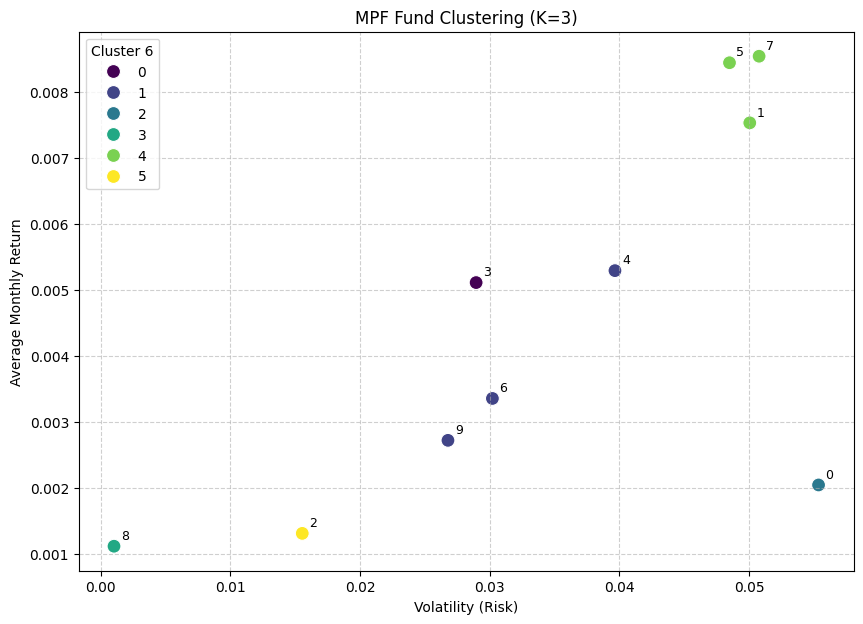

In [38]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='standard deviation', y='average return', hue='Cluster 6', palette='viridis', s=100)

# 為點加上名稱
for i, txt in enumerate(df.index):
    plt.annotate(txt, (df['standard deviation'].iloc[i], df['average return'].iloc[i]), 
                 xytext=(5,5), textcoords='offset points', fontsize=9)

plt.title('MPF Fund Clustering (K=3)')
plt.xlabel('Volatility (Risk)')
plt.ylabel('Average Monthly Return')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [19]:
df

,correlation coefficient with VOO,correlation coefficient with 2800,average return,standard deviation,sharper ratio,maxmium drawdown,Calmar Ratio,Sortino Ratio,downside deviation,Beta with VOO,Apha with VOO,R-square with VOO,Beta with 2800,Apha with 2800,R-square with 2800,Cluster
0,0.431986,0.946031,0.002042,0.055358,0.002830,-0.478475,0.004267,0.004229,0.037044,0.495220,-0.004270,0.186612,0.871762,-0.000853,0.894975,2
1,0.806877,0.547276,0.007526,0.050055,0.112696,-0.310978,0.024202,0.164862,0.034217,0.836384,-0.001835,0.651051,0.456003,0.005113,0.299511,0
2,0.543897,0.460661,0.001309,0.015548,-0.037077,-0.189802,0.006895,-0.054528,0.010572,0.175121,-0.002142,0.295824,0.119225,-0.000715,0.212209,1
3,0.942867,0.465164,0.005107,0.028954,0.111277,-0.204041,0.025029,0.164131,0.019630,0.565331,-0.001831,0.888997,0.224193,0.002962,0.216378,0
4,0.833692,0.758736,0.005288,0.039660,0.085800,-0.290166,0.018224,0.128150,0.026553,0.684700,-0.002717,0.695042,0.500898,0.002823,0.575681,2
5,0.970785,0.390233,0.008437,0.048491,0.135110,-0.242944,0.034727,0.199571,0.032829,0.974837,-0.002162,0.942423,0.314990,0.006187,0.152281,0
6,0.821309,0.723467,0.003352,0.030210,0.048557,-0.245472,0.013655,0.070903,0.020689,0.513804,-0.003126,0.674549,0.363809,0.001045,0.523405,2
7,0.965377,0.409265,0.008535,0.050773,0.130978,-0.287112,0.029728,0.190213,0.034962,1.015033,-0.002422,0.931953,0.345901,0.006250,0.167498,0
8,0.021027,0.078965,0.001114,0.001032,-0.747379,0.000000,0.000000,0.000000,0.000000,0.000449,-0.000775,0.000442,0.001356,-0.000773,0.006235,1
9,0.816931,0.725339,0.002718,0.026783,0.031082,-0.247226,0.010992,0.045921,0.018128,0.453097,-0.003217,0.667376,0.323378,0.000458,0.526117,2


Load the funds data

In [57]:
opt_data = pd.read_excel(xls, 'mpf_monthly_return')
opt_feature=opt_data.drop(['強積金保守基金','Date'],axis=1)

Calculate the average return and covariance matrix

In [58]:
mu=opt_feature.mean()
cov_matrix=opt_feature.cov()
rf=opt_data['強積金保守基金'].mean()


In [55]:
from scipy.optimize import minimize

Optimisation Model and calculate the optimum weight of each fund

In [62]:
def neg_sharpe(weights, mu, cov, rf_rate):
    p_ret = np.sum(mu * weights)
    p_vol = np.sqrt(np.dot(weights.T, np.dot(cov, weights)))
    return -(p_ret - rf_rate) / p_vol

constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
bounds = tuple((0, 1) for _ in range(9))
init_guess = 9 * [1. / 9]

opt_result = minimize(neg_sharpe, init_guess, args=(mu, cov_matrix, rf),
                      method='SLSQP', bounds=bounds, constraints=constraints)

mpf_weights = opt_result.x
mpf_ret = np.sum(mu * mpf_weights)
mpf_vol = np.sqrt(np.dot(mpf_weights.T, np.dot(cov_matrix, mpf_weights)))

print(f"--- 切點組合 (MPF) 結果 ---")
print(f"預期回報: {mpf_ret:.2%}")
print(f"波動率 (風險): {mpf_vol:.2%}")
print(f"最大夏普比率: {-opt_result.fun:.4f}")
print(pd.DataFrame({'fund': opt_feature.columns,
                    'weight': mpf_weights}))

--- 切點組合 (MPF) 結果 ---
預期回報: 0.83%
波動率 (風險): 4.78%
最大夏普比率: 0.1507
         fund        weight
0        中港基金  0.000000e+00
1      亞洲股票基金  1.235471e-01
2      亞洲債券基金  0.000000e+00
3      核心累積基金  0.000000e+00
4        增長組合  0.000000e+00
5      北美股票基金  8.764529e-01
6  基金經理精選退休基金  1.464740e-17
7        美洲基金  2.404126e-16
8        均衡組合  0.000000e+00


Calculate Sharpe Ratio of the optimum weight portfolio

In [68]:
preturn=opt_data['北美股票基金']*0.88+opt_data['亞洲股票基金']*0.12
np.cumprod(1+preturn)
sharper=(np.mean(preturn)-0.19/100)/np.std(preturn)
sharper

np.float64(0.13494778367008897)